Loading Libraries ---

In [2]:
import pandas as pd

Loading Datasets ---

In [3]:
rfm = pd.read_csv("C:/Data Analytics/Projects/Project3 E-commerce Customer Behavior & Revenue Analytics/customer_segments.csv")
clv = pd.read_csv("C:/Data Analytics/Projects/Project3 E-commerce Customer Behavior & Revenue Analytics/clv_analysis.csv")

Verifying Columns ---

In [4]:
rfm.columns

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score',
       'M_Score', 'RFM_Score', 'Segment'],
      dtype='object')

In [5]:
clv.columns

Index(['CustomerID', 'InvoiceNo', 'Revenue', 'AOV', 'Customer_Value', 'CLV',
       'CLV_Segment'],
      dtype='object')

Merging Datasets ---

In [6]:
customer_strategy = pd.merge(
    rfm,
    clv[
        ["CustomerID","CLV","CLV_Segment"]
    ],
    on="CustomerID",
    how="left"
)

Validating ---

In [7]:
customer_strategy.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,CLV,CLV_Segment
0,12346,327,1,77183.60,1,1,5,115,Lost Customers -_-,329729.477916,High Value
1,12347,41,7,4310.00,4,5,5,455,OG-Champions,2630.340512,High Value
2,12348,77,4,1797.24,3,4,4,344,Loyal Customers ;),1919.458949,High Value
3,12349,20,1,1757.55,4,1,4,414,Potential Loyalists ^-^,7508.279530,High Value
4,12350,312,1,334.40,1,1,2,112,Lost Customers -_-,1428.561734,Medium Value


Strategy Rules ---

In [8]:
def business_strategy(row):

    if (
        row["Segment"] == "OG-Champions"
        and
        row["CLV_Segment"] == "High Value"
    ):
        return "VIP Retention"

    elif (
        row["Segment"] == "Loyal Customers ;)"
        and
        row["CLV_Segment"] == "High Value"
    ):
        return "Upsell Opportunity"

    elif (
        row["Segment"] == "At Risk :("
        and
        row["CLV_Segment"] == "High Value"
    ):
        return "Urgent Retention"

    elif (
        row["Segment"] == "Lost Customers -_-"
        and
        row["CLV_Segment"] == "High Value"
    ):
        return "Win Back Campaign"

    elif (
        row["CLV_Segment"] == "Low Value"
    ):
        return "Nurture"

    else:
        return "Growth Opportunity"

In [9]:
customer_strategy["Business_Action"] = (
    customer_strategy.apply(
        business_strategy,
        axis=1
    )
)

Strategy Distribution ---

In [10]:
customer_strategy[
    "Business_Action"
].value_counts()

Business_Action
Growth Opportunity    1687
Nurture               1446
VIP Retention          435
Win Back Campaign      298
Upsell Opportunity     272
Urgent Retention       200
Name: count, dtype: int64

Revenue by Strategy ---

In [11]:
strategy_revenue = (
    customer_strategy
    .groupby("Business_Action")
    ["Monetary"]
    .sum()
    .sort_values(
        ascending=False
    )
)

strategy_revenue

Business_Action
VIP Retention         4389120.190
Growth Opportunity    1979956.481
Upsell Opportunity     832870.650
Nurture                729691.312
Urgent Retention       648320.690
Win Back Campaign      331448.581
Name: Monetary, dtype: float64

Visualization ---

NameError: name 'plt' is not defined

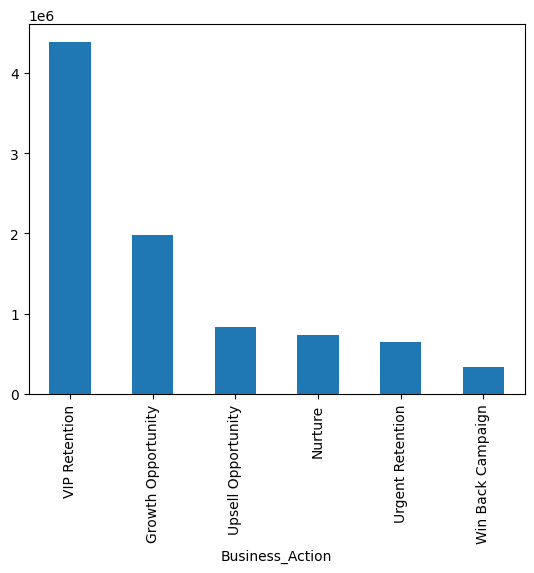

In [12]:
strategy_revenue.plot(
    kind="bar"
)

plt.title("Revenue by Business Strategy")
plt.ylabel("Revenue")
plt.show()

Saving the Output ---

In [14]:
customer_strategy.to_csv("C:/Data Analytics/Projects/Project3 E-commerce Customer Behavior & Revenue Analytics/customer_strategy.csv",
    index=False
)

In [13]:
strategy_summary = (
    customer_strategy
    .groupby("Business_Action")
    .agg(
        Customers=("CustomerID","count"),
        Revenue=("Monetary","sum"),
        Avg_CLV=("CLV","mean")
    )
    .sort_values(
        by="Revenue",
        ascending=False
    )
)

strategy_summary

,Customers,Revenue,Avg_CLV
Business_Action,,,
VIP Retention,435,4389120.190,2966.610445
Growth Opportunity,1687,1979956.481,1502.937713
Upsell Opportunity,272,832870.650,3239.086249
Nurture,1446,729691.312,605.218721
Urgent Retention,200,648320.690,4446.893838
Win Back Campaign,298,331448.581,4350.676888


In [15]:
strategy_summary

,Customers,Revenue,Avg_CLV
Business_Action,,,
VIP Retention,435,4389120.190,2966.610445
Growth Opportunity,1687,1979956.481,1502.937713
Upsell Opportunity,272,832870.650,3239.086249
Nurture,1446,729691.312,605.218721
Urgent Retention,200,648320.690,4446.893838
Win Back Campaign,298,331448.581,4350.676888


In [16]:
strategy_dist = (
    customer_strategy["Business_Action"]
    .value_counts()
)

strategy_dist

Business_Action
Growth Opportunity    1687
Nurture               1446
VIP Retention          435
Win Back Campaign      298
Upsell Opportunity     272
Urgent Retention       200
Name: count, dtype: int64